## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

script_dir = os.getcwd()

# Configure slate dark theme matching Excel and Power BI
plt.rcParams['figure.facecolor'] = '#0F172A'
plt.rcParams['axes.facecolor'] = '#1E293B'
plt.rcParams['text.color'] = '#FFFFFF'
plt.rcParams['axes.labelcolor'] = '#94A3B8'
plt.rcParams['xtick.color'] = '#94A3B8'
plt.rcParams['ytick.color'] = '#94A3B8'
plt.rcParams['axes.edgecolor'] = '#334155'
plt.rcParams['axes.titlecolor'] = '#FFFFFF'
plt.rcParams['grid.color'] = '#334155'
plt.rcParams['font.size'] = 10


## 2. Data Preprocessing & Cleaning
We load the raw monthly oil prices and daily COVID-19 cases, and aggregate them to a quarterly grain.

In [2]:
# Load raw files
raw_oil = pd.read_csv(os.path.join(script_dir, "..", "Raw Data", "crude-oil-price.csv"))
raw_covid = pd.read_csv(os.path.join(script_dir, "..", "Raw Data", "covid_19_clean_complete.csv"))

# Process Oil Prices
raw_oil['date'] = pd.to_datetime(raw_oil['date'])
oil_filtered = raw_oil[(raw_oil['date'].dt.year >= 2009) & (raw_oil['date'].dt.year <= 2022)].copy()
oil_filtered['Year_Quarter'] = oil_filtered['date'].dt.year.astype(str) + "-Q" + oil_filtered['date'].dt.quarter.astype(str)
oil_processed = oil_filtered.groupby('Year_Quarter')['price'].mean().reset_index()
oil_processed.columns = ['Year_Quarter', 'Oil_Price_Qtr_Avg']

# Process COVID Cases
raw_covid['Date'] = pd.to_datetime(raw_covid['Date'])
covid_us = raw_covid[raw_covid['Country/Region'] == 'US'].copy()
covid_us['Year_Quarter'] = covid_us['Date'].dt.year.astype(str) + "-Q" + covid_us['Date'].dt.quarter.astype(str)
covid_processed = covid_us.groupby('Year_Quarter')['Confirmed'].max().reset_index()
covid_processed.columns = ['Year_Quarter', 'COVID_US_Qtr_Cases']

# Save processed files directly
oil_processed.to_excel(os.path.join(script_dir, "..", "Excel", "Processed Data", "Oil_Qtr.xlsx"), index=False)
covid_processed.to_excel(os.path.join(script_dir, "..", "Excel", "Processed Data", "Covid_US_Cases_Quarter.xlsx"), index=False)
print("Preprocessing completed and processed Excel sheets updated!")

Preprocessing completed and processed Excel sheets updated!


## 3. Data Loading & Merging
Now we load the master fact tables and dimensions from the Excel workbook, and merge them on Date_Key.

In [3]:
excel_file = os.path.join(script_dir, "..", "Excel", "Master_Tables_file.xlsx")

dim_time = pd.read_excel(excel_file, sheet_name='Dim_Time')
fact_fin = pd.read_excel(excel_file, sheet_name='Fact_Financials_Master')
oil_prices = pd.read_excel(excel_file, sheet_name='Oil_Prices_Avg_Qtr')
covid_cases = pd.read_excel(excel_file, sheet_name='covid_19_clean_complete')

# Merge datasets on Date_Key
df = fact_fin.merge(dim_time, on='Date_Key', how='left')
df = df.merge(oil_prices.rename(columns={'Oil_Bucket': 'Oil_Bucket_Oil'}), on='Date_Key', how='left')
df = df.merge(covid_cases, on='Date_Key', how='left')
df['Covid_US_Cases_Quarterly'] = df['Covid_US_Cases_Quarterly'].fillna(0)

print("Data loaded and merged successfully!")

Data loaded and merged successfully!


## 4. Aligning the financial units and creating period flags for comparison.


In [4]:
# Align fuel cost (raw dollars) to $thousands grain
df['fuel_cost_k'] = df['fuel_cost'] / 1000
df['operating_margin_pct'] = (df['operating_income'] / df['operating_revenue']) * 100

# Define period categories
def get_period(qtr):
    year = int(qtr[:4])
    quarter = qtr[5:]
    if year < 2020:
        return 'Pre_COVID'
    elif year == 2020 or (year == 2021 and quarter in ['Q1', 'Q2']):
        return 'COVID_Shock'
    else:
        return 'Recovery'

df['Period_Group'] = df['Year_Quarter'].apply(get_period)

# Set categorical order
oil_order = ['Below_50', '50_to_80', '80_to_100', '100_Plus']
df['Oil_Bucket'] = pd.Categorical(df['Oil_Bucket'], categories=oil_order, ordered=True)
df['Year'] = df['Year_Quarter'].str[:4].astype(int)

## 5. Statistical Aggregations

In [5]:
# 1. Descriptive stats
airline_stats = df.groupby('Airline_Name').agg(
    Quarters_Count=('Date_Key', 'count'),
    Total_Revenue_M=('operating_revenue', lambda x: round(x.sum() / 1000, 1)),
    Total_Op_Income_M=('operating_income', lambda x: round(x.sum() / 1000, 1)),
    Avg_Load_Factor_Pct=('load_factor', 'mean'),
    Weighted_Margin_Pct=('operating_income', lambda x: round(x.sum() / df.loc[x.index, 'operating_revenue'].sum() * 100, 2)),
    Loss_Quarters=('operating_income', lambda x: (x < 0).sum())
).reset_index()
airline_stats['Loss_Rate_Pct'] = (airline_stats['Loss_Quarters'] / airline_stats['Quarters_Count'] * 100).round(1)
airline_stats = airline_stats.sort_values('Weighted_Margin_Pct', ascending=False).reset_index(drop=True)

# 2. Period averages
period_summary = df.groupby('Period_Group', observed=True).agg(
    Avg_Load_Factor=('load_factor', 'mean'),
    Avg_Margin=('operating_margin_pct', 'mean'),
    Avg_WTI_Price=('Oil_Price_Qtr_Avg', 'mean'),
    Loss_Rate_Pct=('operating_income', lambda x: (x < 0).mean() * 100)
).reset_index()

# 3. Pearson Correlation matrix
corr_cols = ['Oil_Price_Qtr_Avg', 'Covid_US_Cases_Quarterly', 'operating_income', 'operating_margin_pct', 'load_factor', 'fuel_cost_k']
corr_matrix = df[corr_cols].corr().round(3)

# 4. YoY revenue growth table
yearly_rev = df.groupby(['Airline_Name', 'Year'])['operating_revenue'].sum().reset_index()
yearly_rev['YoY_Growth_Pct'] = yearly_rev.groupby('Airline_Name')['operating_revenue'].pct_change() * 100

print("Statistical suite calculated!")

Statistical suite calculated!


## 6. Visualizations

### Chart 1: Average Quarterly Operating Income (CARES vs Normal period)

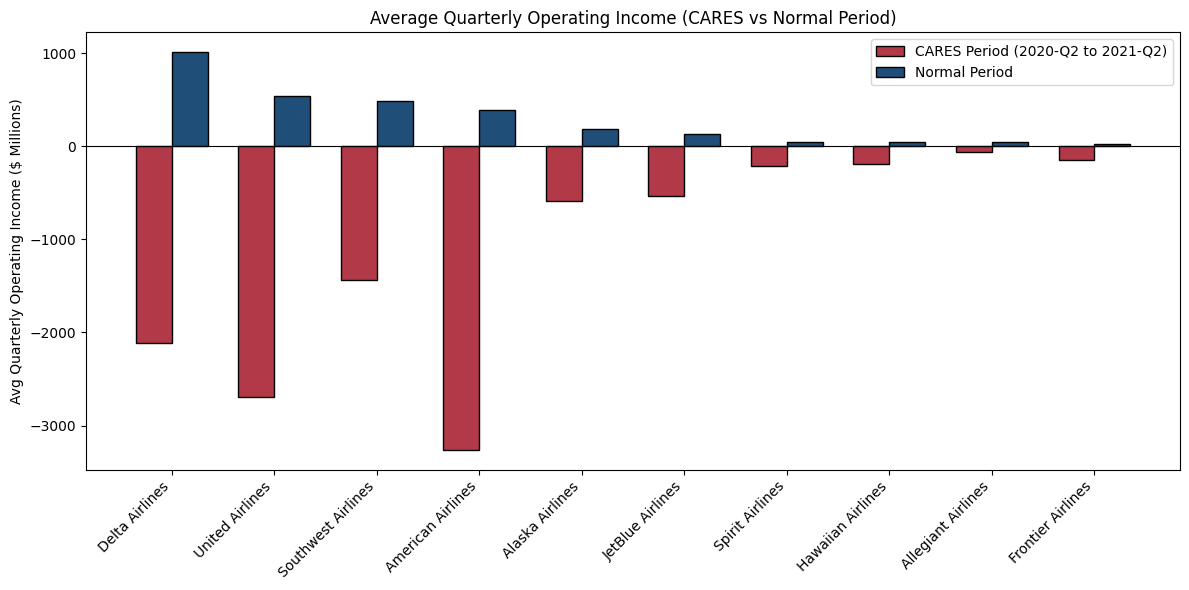

In [6]:
period_op_inc = df.groupby(['Airline_Name', 'CARES_FLAG'])['operating_income'].mean().unstack()
period_op_inc = period_op_inc.sort_values('Normal_Period', ascending=False).reset_index()

x = np.arange(len(period_op_inc))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, period_op_inc['CARES_Period']/1000, width, label='CARES Period (2020-Q2 to 2021-Q2)', color='#DC2626', edgecolor='#334155')
plt.bar(x + width/2, period_op_inc['Normal_Period']/1000, width, label='Normal Period', color='#2563EB', edgecolor='#334155')
plt.xticks(x, period_op_inc['Airline_Name'], rotation=45, ha='right')
plt.ylabel('Avg Quarterly Operating Income ($ Millions)')
plt.title('Average Quarterly Operating Income (CARES vs Normal Period)')
plt.axhline(0, color='#334155', linestyle='-', linewidth=0.8)
plt.legend(facecolor='#1E293B', edgecolor='#334155')
plt.tight_layout()
plt.show()


### Chart 2: Recovery Profile: Annual Income vs Revenue (2018-2022)

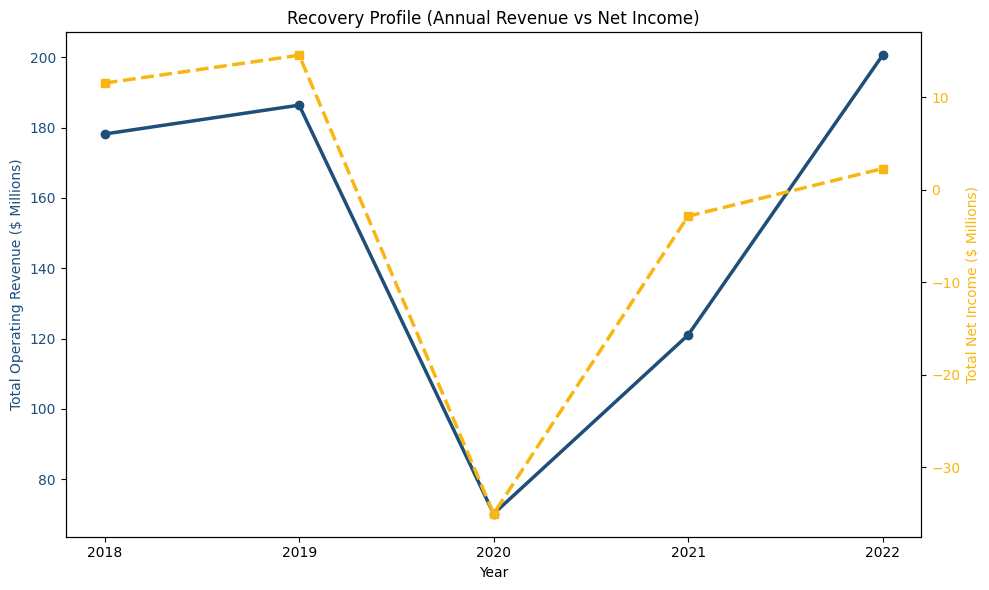

In [7]:
annual_summary = df[(df['Year'] >= 2018) & (df['Year'] <= 2022)].groupby('Year').agg(
    Revenue=('operating_revenue', 'sum'),
    Net_Income=('net_income', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Plot on ax1 (left axis)
ax1.plot(annual_summary['Year'].astype(str), annual_summary['Revenue']/1000000, color='#2563EB', marker='o', linewidth=2.5, label='Operating Revenue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Operating Revenue ($ Millions)', color='#2563EB')
ax1.tick_params(axis='y', labelcolor='#2563EB')

# Plot on ax2 (right axis)
ax2.plot(annual_summary['Year'].astype(str), annual_summary['Net_Income']/1000000, color='#D97706', marker='s', linewidth=2.5, linestyle='--', label='Net Income')
ax2.set_ylabel('Total Net Income ($ Millions)', color='#D97706')
ax2.tick_params(axis='y', labelcolor='#D97706')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', facecolor='#1E293B', edgecolor='#334155')

plt.title('Recovery Profile (Annual Revenue vs Net Income)')
fig.tight_layout()
plt.show()


### Chart 3: Operating Revenue for Airlines

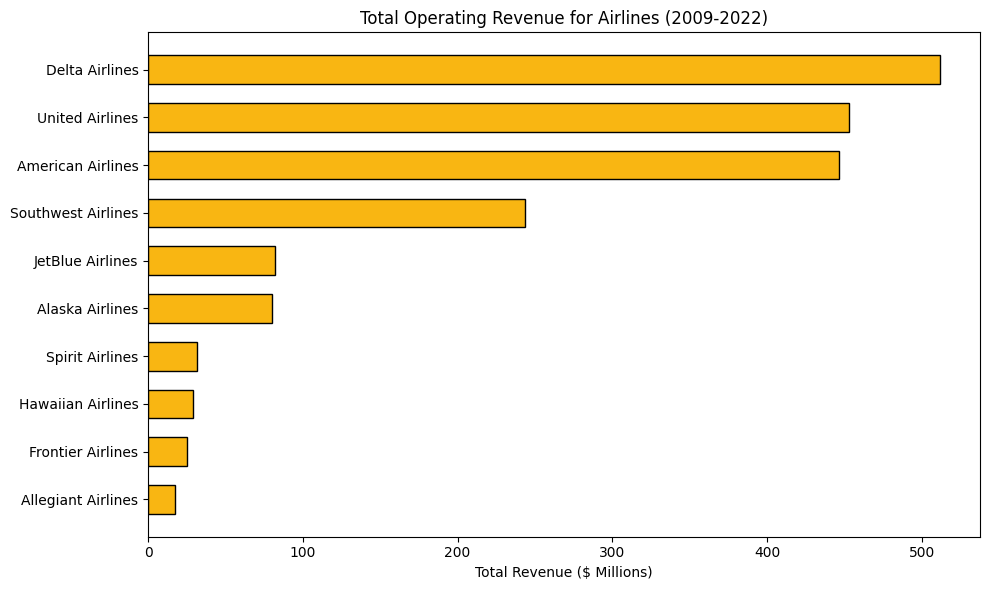

In [8]:
revenue_ranking = df.groupby('Airline_Name')['operating_revenue'].sum().reset_index()
revenue_ranking = revenue_ranking.sort_values('operating_revenue', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(revenue_ranking['Airline_Name'], revenue_ranking['operating_revenue']/1000000, color='#2563EB', edgecolor='#334155', height=0.6)
plt.title('Total Operating Revenue for Airlines (2009-2022)')
plt.xlabel('Total Revenue ($ Millions)')
plt.tight_layout()
plt.show()


### Chart 4: Net Financial Assistance by Airline (Bailout Cushion)

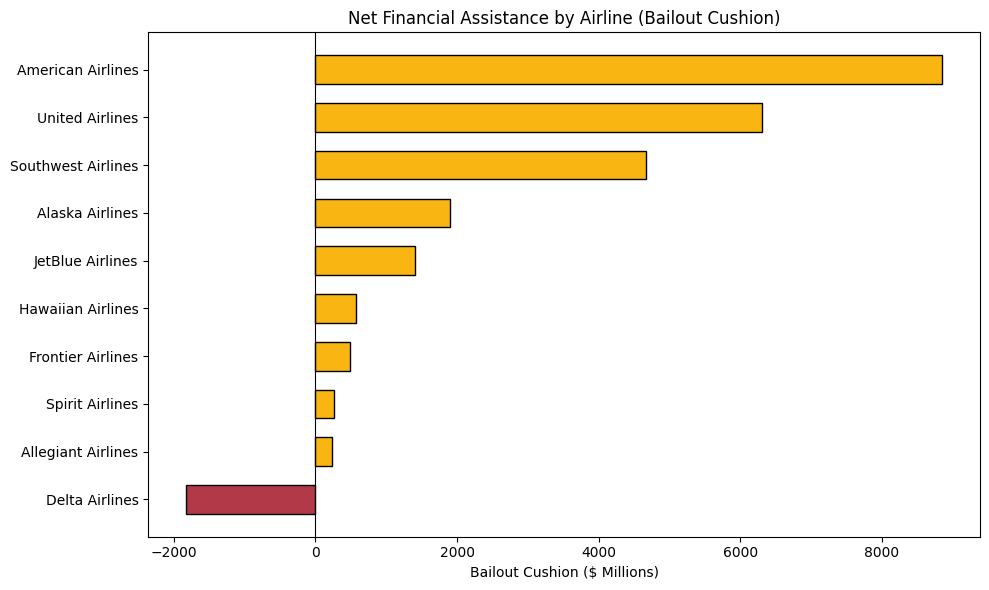

In [9]:
cares_df = df[df['CARES_FLAG'] == 'CARES_Period']
bailout_cushion = cares_df.groupby('Airline_Name').apply(
    lambda x: (x['net_income'].sum() - x['operating_income'].sum()) / 1000
).reset_index(name='Bailout_Cushion_M')
bailout_cushion = bailout_cushion.sort_values('Bailout_Cushion_M', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#DC2626' if x < 0 else '#D97706' for x in bailout_cushion['Bailout_Cushion_M']]
plt.barh(bailout_cushion['Airline_Name'], bailout_cushion['Bailout_Cushion_M'], color=colors, edgecolor='#334155', height=0.6)
plt.title('Net Financial Assistance by Airline (Bailout Cushion)')
plt.xlabel('Bailout Cushion ($ Millions)')
plt.axvline(0, color='#334155', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()


### Chart 5: Revenue Margin vs Oil Price Brackets

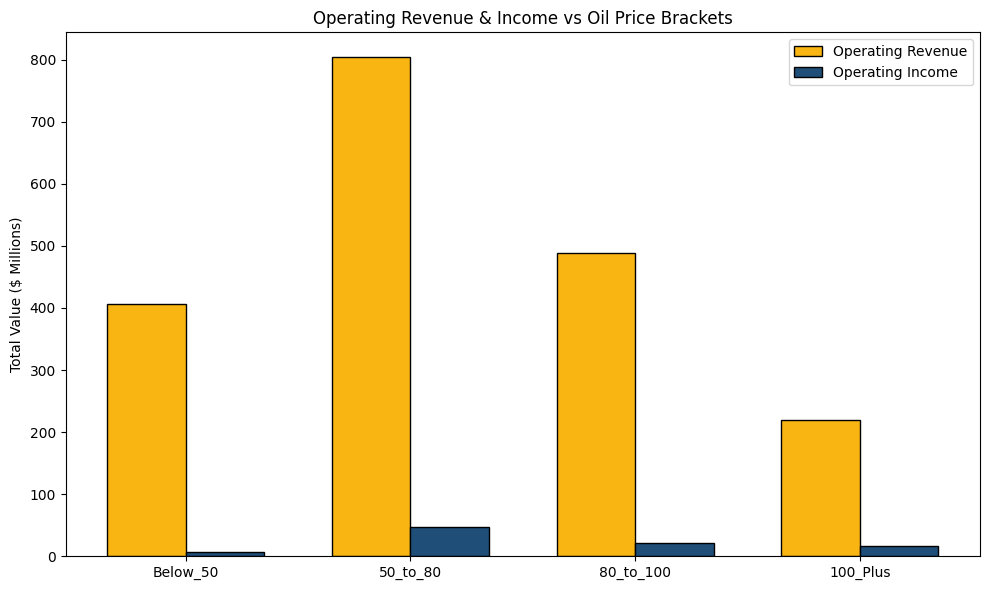

In [10]:
oil_bracket_summary = df.groupby('Oil_Bucket', observed=True).agg(
    Revenue=('operating_revenue', 'sum'),
    Income=('operating_income', 'sum')
).reset_index()
oil_bracket_summary['Margin'] = (oil_bracket_summary['Income'] / oil_bracket_summary['Revenue'])

x_oil = np.arange(len(oil_bracket_summary))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Columns on ax1
ax1.bar(x_oil - width/2, oil_bracket_summary['Revenue']/1000000, width, label='Operating Revenue', color='#D97706', edgecolor='#334155')
ax1.bar(x_oil + width/2, oil_bracket_summary['Income']/1000000, width, label='Operating Income', color='#2563EB', edgecolor='#334155')
ax1.set_ylabel('Total Value ($ Millions)', color='#94A3B8')

# Line on ax2
ax2.plot(x_oil, oil_bracket_summary['Margin'], color='#22C55E', marker='o', linewidth=2.5, label='Revenue Margin')
ax2.set_ylabel('Revenue Margin', color='#22C55E')
ax2.tick_params(axis='y', labelcolor='#22C55E')

ax1.set_xticks(x_oil)
ax1.set_xticklabels(oil_bracket_summary['Oil_Bucket'])

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', facecolor='#1E293B', edgecolor='#334155')

plt.title('Operating Revenue & Income vs Oil Price Brackets')
fig.tight_layout()
plt.show()


## 7. Additional Insightful Charts

### Chart 6: COVID Collapse - Pre vs Shock

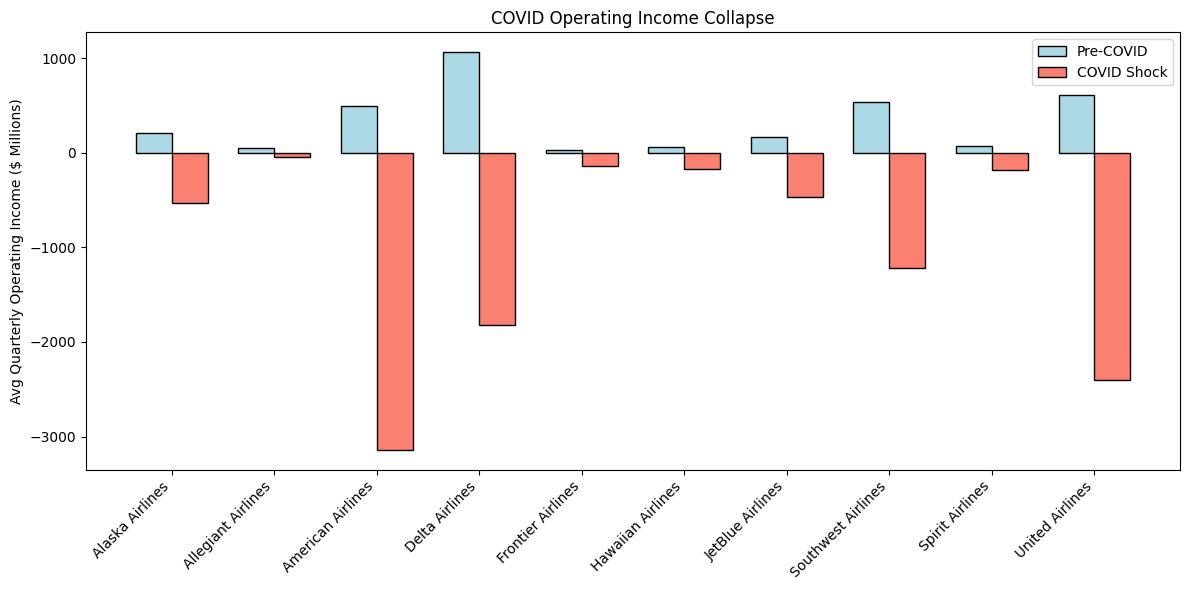

In [11]:
collapse = df.groupby(['Airline_Name', 'Period_Group'], observed=True)['operating_income'].mean().unstack()
collapse = collapse[['Pre_COVID', 'COVID_Shock']].dropna().reset_index()

x_coll = np.arange(len(collapse))
w_coll = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x_coll - w_coll/2, collapse['Pre_COVID']/1000, w_coll, label='Pre-COVID', color='#2563EB', edgecolor='#334155')
plt.bar(x_coll + w_coll/2, collapse['COVID_Shock']/1000, w_coll, label='COVID Shock', color='#DC2626', edgecolor='#334155')
plt.xticks(x_coll, collapse['Airline_Name'], rotation=45, ha='right')
plt.ylabel('Avg Quarterly Operating Income ($ Millions)')
plt.title('COVID Operating Income Collapse')
plt.legend(facecolor='#1E293B', edgecolor='#334155')
plt.tight_layout()
plt.show()


### Chart 7: Load Factor vs Operating Margin Timeline

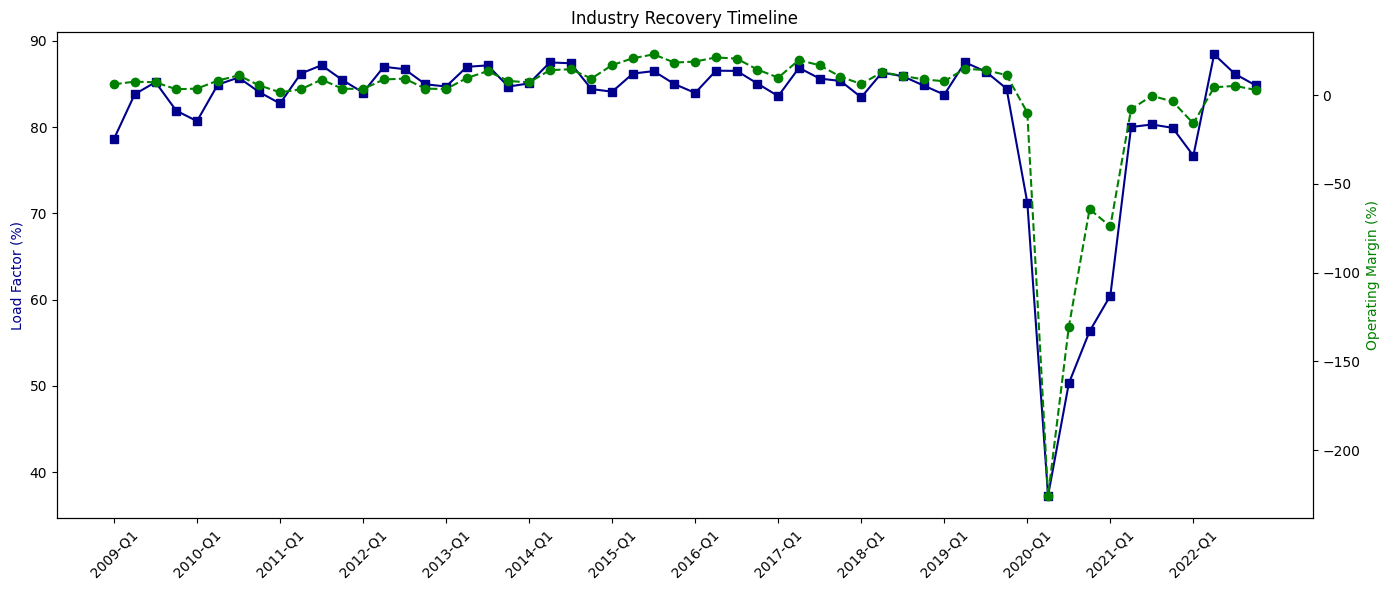

In [12]:
timeline = df.groupby('Year_Quarter').agg(
    Avg_LF=('load_factor', 'mean'),
    Avg_Margin=('operating_margin_pct', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Plot Load Factor
ax1.plot(timeline['Year_Quarter'], timeline['Avg_LF'], color='#2563EB', marker='s', label='Avg Load Factor (%)')
ax1.set_ylabel('Load Factor (%)', color='#2563EB')
ax1.tick_params(axis='y', labelcolor='#2563EB')

# Plot Margin
ax2.plot(timeline['Year_Quarter'], timeline['Avg_Margin'], color='#22C55E', marker='o', linestyle='--', label='Avg Operating Margin (%)')
ax2.set_ylabel('Operating Margin (%)', color='#22C55E')
ax2.tick_params(axis='y', labelcolor='#22C55E')

ax1.set_xticks(timeline['Year_Quarter'][::4])
ax1.set_xticklabels(timeline['Year_Quarter'][::4], rotation=45)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', facecolor='#1E293B', edgecolor='#334155')

plt.title('Industry Recovery Timeline')
fig.tight_layout()
plt.show()


### Chart 8: Correlation Matrix of Variables

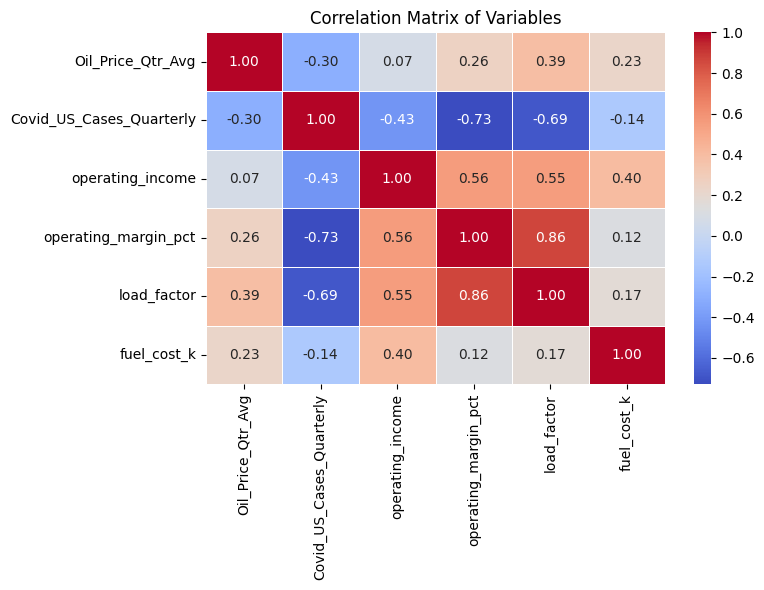

In [13]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Variables')
plt.tight_layout()
plt.show()